In [1]:
#Cleaning dataset Clients Profile
#Que informacion tiene? Datos de los perfiles de clientes de Vanguard: datos demográficos, balances economicos, cómo interactuan con la plataforma (call_6_month, logons_6_month)
#Algo que mencionar: estas variables: call_6_month, logons_6_month no especifican que process se utilizo: traditional or digital interface. 

In [2]:
#1. Importar dataset

import pandas as pd

df_demo = pd.read_csv("Datasets/df_final_demo.txt")

In [3]:
#2.a. Exploracion del dataset
df_demo. info()

<class 'pandas.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  str    
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 4.8 MB


In [4]:
df_demo.shape

(70609, 9)

In [5]:
df_demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [6]:
#2.b Revisar los valores nulos
df_demo.isnull().sum()
#Podemos decir que el dataset tiene buena calidad, ya que de 70609 filas solo 14-15 son valores nulos. 

client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

In [7]:
#Vamos a comprobar qué filas tienen al menos un null.
df_demo[df_demo.isnull().any(axis=1)]

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
4164,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8316,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8677,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9583,4666211,8.0,106.0,NaN,F,2.0,42550.55,4.0,7.0
13444,2222915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18066,4876926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25961,5277910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28432,7616759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35323,8191345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43518,1227228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
#Vamos a eliminar filas totalmente vacias. 

df_demo[df_demo.iloc[:, 1:].isnull().all(axis=1)]

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
4164,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8316,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8677,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13444,2222915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18066,4876926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25961,5277910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28432,7616759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35323,8191345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43518,1227228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46076,8611797,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df_demo[df_demo.iloc[:, 1:].isnull().all(axis=1)].shape

(14, 9)

In [10]:
df_demo = df_demo.dropna(how="all", subset=df_demo.columns[1:])

In [11]:
df_demo.shape

(70595, 9)

In [12]:
#2.c Revisar los duplicados

df_demo.duplicated().sum()

#Vemos que no hay valores duplicados en el dataset. 

np.int64(0)

In [13]:
#Vamos a comprobar si client_id se repite porque un cliente deberia aparecer una sola vez. 
df_demo["client_id"].duplicated().sum()

np.int64(0)

In [14]:
#2.d Vamos a revisar las variables categoricas: gender solo en este caso. 

df_demo["gendr"].value_counts(dropna=False)

gendr
U    24122
M    23724
F    22746
X        3
Name: count, dtype: int64

In [15]:
#Vamos a revisar esas filas con gender X para ver que decision tomar.
df_demo[df_demo["gendr"] == "X"]

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
17728,4806791,11.0,136.0,40.0,X,2.0,31437.35,6.0,9.0
19475,5537155,9.0,113.0,26.0,X,2.0,25380.34,1.0,4.0
53592,1807720,9.0,110.0,52.0,X,3.0,25710.63,4.0,5.0


In [16]:
#Vemos que solo hay 3 filas con gender X, por lo que debemos reemplazar X por U, que significa Unknown. Por lo que tendriamos 3 categorias: Female, Male and Unknown.
df_demo["gendr"] = df_demo["gendr"].replace("X", "U")
df_demo["gendr"].value_counts(dropna=False)

gendr
U    24125
M    23724
F    22746
Name: count, dtype: int64

In [17]:
#2.e Vamos a revisar las variables númericas: clnt_age, bal, call_6_month, logons_6_month, num_accts, clnt_tenure*
df_demo.describe()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,7.059500e+04,70595.000000,70595.000000,70594.000000,70595.000000,7.059500e+04,70595.000000,70595.000000
mean,5.005021e+06,12.052950,150.659367,46.442240,2.255528,1.474452e+05,3.382478,5.566740
std,2.877269e+06,6.871819,82.089854,15.591273,0.534997,3.015087e+05,2.236580,2.353286
min,1.690000e+02,2.000000,33.000000,13.500000,1.000000,1.378942e+04,0.000000,1.000000
25%,2.519604e+06,6.000000,82.000000,32.500000,2.000000,3.734683e+04,1.000000,4.000000
50%,5.016969e+06,11.000000,136.000000,47.000000,2.000000,6.333290e+04,3.000000,5.000000
75%,7.483064e+06,16.000000,192.000000,59.000000,2.000000,1.375449e+05,6.000000,7.000000
max,9.999839e+06,62.000000,749.000000,96.000000,8.000000,1.632004e+07,7.000000,9.000000


In [18]:
#Comentarios:
1. Edad min es de 13.5 años, no tiene mucho sentido que cliente de esta edad tengan inversion financiera.
2. En la variable bal, podemos ver de media 147K, y el maximo es de 16.3 millones

SyntaxError: invalid decimal literal (2306838627.py, line 3)

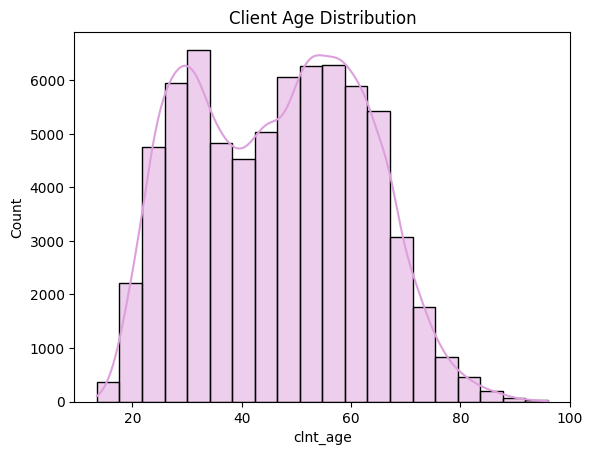

In [ ]:
#2.f Vamos a analizar estas dos variables con visuals.
#Variable: age
#1. Histograma para comprobar la distribución. 
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=df_demo, x="clnt_age", bins=20, color='plum', kde=True)

plt.title("Client Age Distribution")
plt.show()

In [ ]:
#Comentarios del histograma:
- Los valores se concentran principalmente entre 30-65 años
- Vemos pocos clientes jovenes, menores de 20 años y tambien vemos hay pocos clientes con elevada edad, 90 años. 

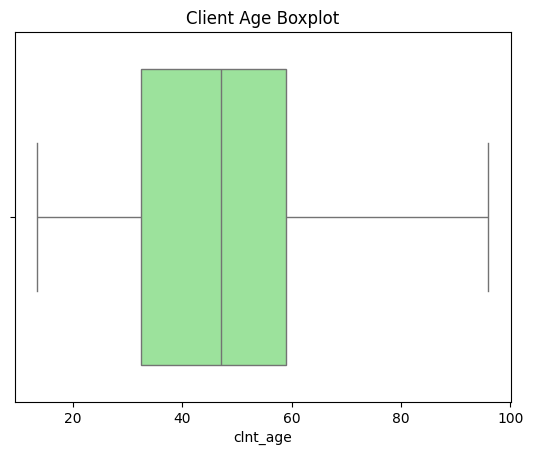

In [ ]:
#2. Boxplot para analizar los outliers. 
sns.boxplot(data=df_demo, x="clnt_age", color="lightgreen")

plt.title("Client Age Boxplot")
plt.show()

In [ ]:
#Comentarios del boxplot:
- Me sorprende que no veamos outliers, clientes con edad inferior a 20 años. 
- La mediana esta en 47 años aprox. 

SyntaxError: invalid syntax (1075327420.py, line 2)

In [ ]:
#Vamos a profundizar un poco en ese valor minimo de edad que hemos visto antes:
df_demo[df_demo["clnt_age"] < 18]

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
768,5249795,17.0,208.0,17.5,M,3.0,43042.88,3.0,6.0
1194,4286237,21.0,257.0,17.5,F,2.0,32577.78,5.0,8.0
2283,5269888,20.0,243.0,17.5,F,2.0,39631.34,6.0,9.0
2716,6516140,5.0,66.0,17.5,U,2.0,74939.63,6.0,9.0
2846,5114008,4.0,57.0,17.5,U,2.0,30585.96,1.0,4.0
...,...,...,...,...,...,...,...,...,...
70307,1828490,23.0,276.0,14.5,M,2.0,30214.58,3.0,3.0
70437,699213,23.0,286.0,17.0,M,2.0,29734.42,6.0,6.0
70534,4058574,5.0,66.0,17.0,U,2.0,31265.21,3.0,3.0
70576,2352946,14.0,169.0,17.0,M,2.0,27022.35,4.0,4.0


In [ ]:
#Comentarios:
- Vemos muchas filas con edades menores a 18 años, lo cual podriamos interpretar que son valores correctos: puede ser que padres/familiares le hayan abierto una cuenta a sus hijos siendo menores. 

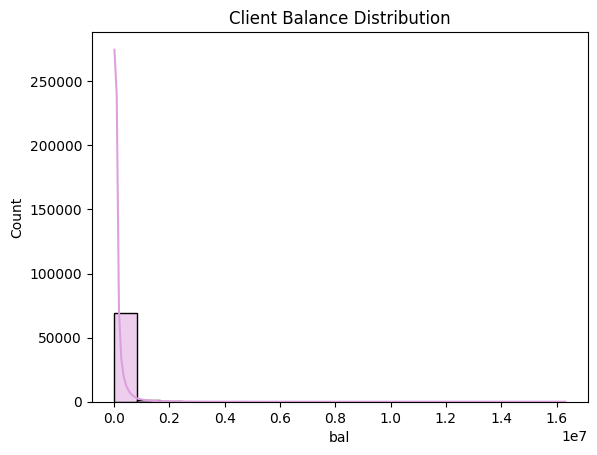

In [ ]:
#Variable: Balance
#1. Histograma para comprobar la distribución.
sns.histplot(data=df_demo, x="bal", bins=20, color='plum', kde=True)

plt.title("Client Balance Distribution")
plt.show()

In [ ]:
#Comentarios:
- Podemos decir que la distribucion de balance esta muy sesgada a la derecha, lo cual nos dice que la mayoria de los clientes tienen balances normales, pero un grupo reducido de clientes tienen balances grandes. 


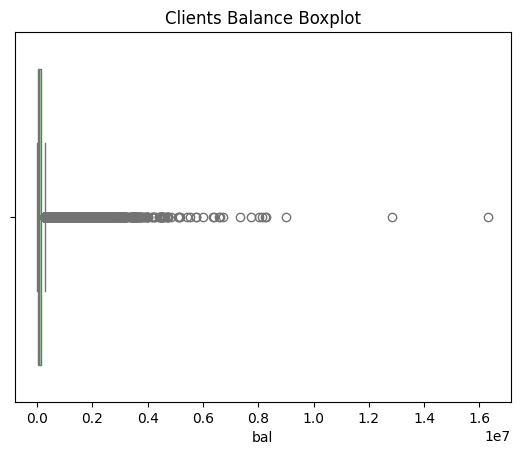

In [ ]:
#2. Boxplot para analizar los outliers. 
sns.boxplot(data=df_demo, x="bal", color="lightgreen")

plt.title("Clients Balance Boxplot")
plt.show()

In [ ]:
#Comentarios: 
- Podemos ver aqui que hay muchos outliers, clientes con balances muy altos y concentracion enorme de clientes con balances más bajos. 
- Los clientes multimillonarios "aplastan" las cajas, el IQR es inexistente. 

In [ ]:
#2.g Vamos a revisar ahora las variables de tiempo: clnt_tenure_yr + clnt_tenure_mnth porque queremos ver si los valores como años y mes son coherentes entre sí.
df_demo[["clnt_tenure_yr", "clnt_tenure_mnth"]].head(20)

,clnt_tenure_yr,clnt_tenure_mnth
0,6.0,73.0
1,7.0,94.0
2,5.0,64.0
3,16.0,198.0
4,12.0,145.0
5,5.0,71.0
6,5.0,66.0
7,30.0,361.0
8,30.0,369.0
9,15.0,189.0


In [ ]:
#Ya podemos comprobar aqui que clnt_tenure_mnth != clnt_tenure_yr * 12, lo cual nos indica que la columna de year esta redondeada. 
#Columna clnt_tenure_yr es mas precisa, lo cual debemos considerar en el analisis posterior. No vamos a borrar la columna referente al year por si acaso. 

In [ ]:
#2.h Exportar dataset limpio a CSV y guardarlos en la carpeta de Datasets_limpios.
df_demo.to_csv("Datasets_limpios/clean_client_profiles.csv", index=False)